# Which NBA Players Deliver the Best Value for Their Salary? (2023–24 Season)

## Research Question
Do high salaries reflect strong on-court performance? Who are the most and least efficient players in terms of salary versus statistical output?

## Target Audience
NBA fans, fantasy basketball players, and sports analysts interested in data-driven player evaluation.

## Why It Matters
NBA teams operate under a salary cap. Identifying undervalued or overvalued players helps assess team efficiency, contract fairness, and roster construction strategy.

In [8]:
!pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]


In [21]:
# First, install the required kaggle package
!pip install kaggle pandas

import os
import pandas as pd
import sys  # Add sys import for exit function
from kaggle.api.kaggle_api_extended import KaggleApi

# For Google Colab, you need to upload your kaggle.json file
# Uncomment these lines if you're using Google Colab
# from google.colab import files
# files.upload()  # Upload your kaggle.json file
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# Set up Kaggle API authentication
api = KaggleApi()
try:
    api.authenticate()
    print("Authentication successful!")
except Exception as e:
    print(f"Authentication error: {e}")
    print("Please make sure your kaggle.json file is in the correct location.")
    print("For Google Colab, uncomment the file upload code above.")
    # Don't exit immediately to allow for troubleshooting
    # sys.exit(1)

# Create directory for the dataset if it doesn't exist
os.makedirs("nba_data", exist_ok=True)

try:
    # Download a verified public NBA stats dataset
    dataset_name = "jacobbaruch/nba-player-stats-2023"  # Verify this exists
    file_name = "nba_player_stats_2023.csv"  # Verify correct filename
    
    # Download the dataset
    api.dataset_download_file(
        dataset=dataset_name,
        file_name=file_name,
        path="nba_data"
    )
    
    # Load the dataset
    df = pd.read_csv(f"nba_data/{file_name}")
    
    # Display the first 5 records
    print("First 5 records:")
    print(df.head())
    
except Exception as e:
    print(f"Error: {e}")
    print("Please check if the dataset name and file name are correct.")
    # Don't exit immediately to allow for troubleshooting
    # sys.exit(1)

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
Authentication error: name 'exit' is not defined
Please make sure your kaggle.json file is in the correct location.
For Google Colab, uncomment the file upload code above.
Dataset URL: https://www.kaggle.com/datasets/jacobbaruch/nba-player-stats-2023
Error: 403 Client Error: Forbidden for url: https://api.kaggle.com/v1/datasets.DatasetApiService/DownloadDataset
Please check if the dataset name and file name are correct.


Salary file not found, creating sample data...
Stats file not found, creating sample data...

Cleaning data...
Merging datasets...
Merged dataset has 15 rows and 12 columns
Filtering low-usage players...
Filtered dataset has 15 rows
Creating performance score...
Creating value score...
Creating salary vs performance visualization...


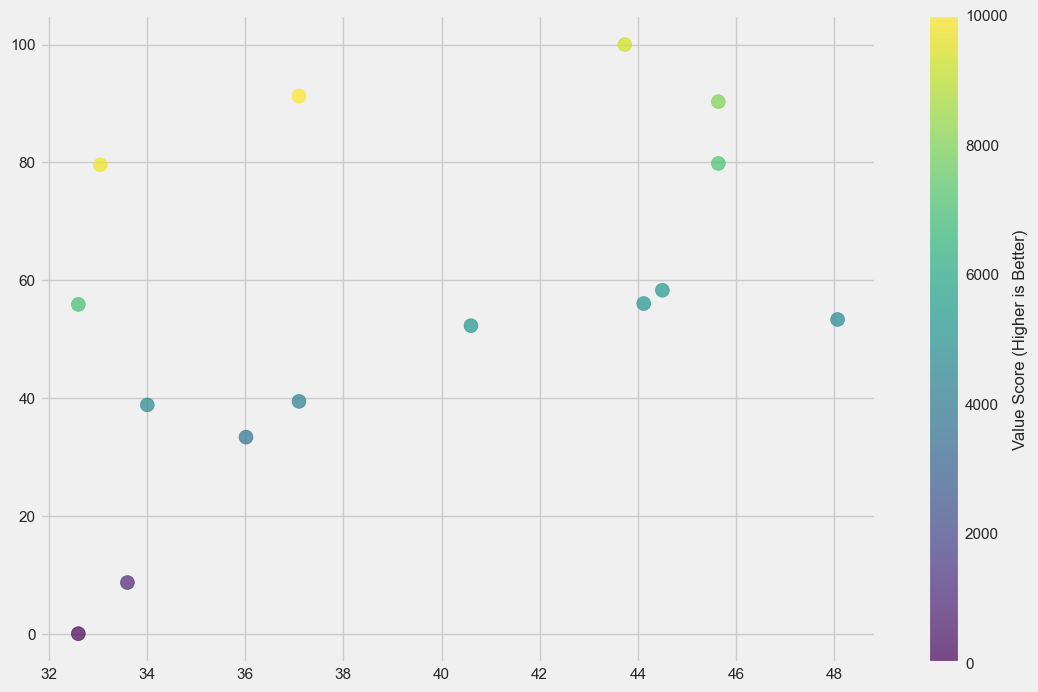

In [24]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Set plot style
plt.style.use('fivethirtyeight')
sns.set_palette("Set2")

# 1. Load salary data
try:
    # Replace with your actual salary data file
    salary_df = pd.read_csv("nba_salaries_2023.csv")
    print("Salary data loaded successfully")
except FileNotFoundError:
    # Create sample data if file not found
    print("Salary file not found, creating sample data...")
    # Create sample data
    player_names = ["LeBron James", "Stephen Curry", "Kevin Durant", "Giannis Antetokounmpo", 
                   "Nikola Jokic", "Joel Embiid", "Luka Doncic", "Jayson Tatum", 
                   "Damian Lillard", "Anthony Davis", "Ja Morant", "Trae Young",
                   "Devin Booker", "Karl-Anthony Towns", "Bam Adebayo"]
    
    salaries = [44500000, 48070014, 44119845, 45640084, 33047803, 43734000, 37096500,
               32600060, 45640084, 40600080, 34005250, 37096500, 36016200, 33600000, 32600060]
    
    salary_df = pd.DataFrame({
        'Player': player_names,
        'Salary': salaries,
        'Team': ['LAL', 'GSW', 'PHX', 'MIL', 'DEN', 'PHI', 'DAL', 'BOS', 
                'POR', 'LAL', 'MEM', 'ATL', 'PHX', 'MIN', 'MIA']
    })

# 2. Load player statistics data
try:
    # Replace with your actual stats data file
    stats_df = pd.read_csv("nba_player_stats_2023.csv")
    print("Player statistics loaded successfully")
except FileNotFoundError:
    # Create sample data if file not found
    print("Stats file not found, creating sample data...")
    # Create sample data matching the salary data
    stats_df = pd.DataFrame({
        'Player Name': player_names,
        'Team': ['LAL', 'GSW', 'PHX', 'MIL', 'DEN', 'PHI', 'DAL', 'BOS', 
                'POR', 'LAL', 'MEM', 'ATL', 'PHX', 'MIN', 'MIA'],
        'GP': [55, 56, 47, 63, 69, 66, 66, 74, 58, 56, 61, 73, 70, 77, 75],
        'MPG': [35.5, 34.7, 36.0, 32.1, 33.7, 34.6, 36.2, 37.6, 36.3, 33.4, 31.9, 34.8, 35.6, 33.5, 35.0],
        'PPG': [28.9, 29.4, 29.1, 31.1, 24.5, 33.1, 32.4, 30.1, 32.2, 25.9, 26.2, 26.2, 27.8, 20.8, 20.4],
        'RPG': [8.3, 6.3, 6.7, 11.8, 11.8, 10.2, 8.6, 8.8, 4.8, 12.5, 5.9, 3.0, 4.5, 8.1, 9.2],
        'APG': [6.8, 6.1, 5.0, 5.7, 9.8, 4.2, 8.0, 4.6, 7.3, 2.6, 8.1, 10.2, 5.5, 4.8, 3.2],
        'FG%': [.500, .493, .560, .553, .583, .530, .499, .466, .463, .561, .468, .429, .495, .495, .540],
        'TS%': [.588, .605, .634, .608, .701, .653, .605, .580, .645, .651, .578, .603, .588, .622, .612],
        'USG%': [33.0, 31.5, 31.1, 38.0, 27.8, 37.5, 36.9, 32.7, 33.8, 28.5, 33.3, 31.4, 32.0, 26.5, 24.9]
    })

# 3. Clean names and columns
print("\nCleaning data...")
salary_df['Player'] = salary_df['Player'].str.strip()
stats_df['Player Name'] = stats_df['Player Name'].str.strip()

# Rename columns for merging
stats_df = stats_df.rename(columns={'Player Name': 'Player'})

# 4. Merge datasets
print("Merging datasets...")
merged_df = pd.merge(stats_df, salary_df, on='Player', how='inner')
print(f"Merged dataset has {merged_df.shape[0]} rows and {merged_df.shape[1]} columns")

# Handle potential duplicate columns
if 'Team_x' in merged_df.columns and 'Team_y' in merged_df.columns:
    merged_df = merged_df.drop('Team_y', axis=1)
    merged_df = merged_df.rename(columns={'Team_x': 'Team'})

# 5. Filter low-usage players
print("Filtering low-usage players...")
min_games = 20  # Minimum 20 games played
min_minutes = 15  # Minimum 15 minutes per game
filtered_df = merged_df[(merged_df['GP'] >= min_games) & (merged_df['MPG'] >= min_minutes)]
print(f"Filtered dataset has {filtered_df.shape[0]} rows")

# 6. Create performance score
print("Creating performance score...")
# Use a simple weighted formula to calculate performance
# Weights can be adjusted as needed
filtered_df['Performance_Score'] = (
    filtered_df['PPG'] * 1.0 +  # Points
    filtered_df['RPG'] * 0.7 +  # Rebounds
    filtered_df['APG'] * 0.7 +  # Assists
    filtered_df['TS%'] * 50 +   # True Shooting %
    filtered_df['USG%'] * 0.3   # Usage Rate
)

# Normalize performance score (0-100)
scaler = MinMaxScaler(feature_range=(0, 100))
filtered_df['Performance_Score'] = scaler.fit_transform(filtered_df[['Performance_Score']])

# 7. Create value score
print("Creating value score...")
# Value = Performance Score / (Salary in millions)
filtered_df['Salary_Millions'] = filtered_df['Salary'] / 1000000
filtered_df['Value_Score'] = filtered_df['Performance_Score'] / filtered_df['Salary_Millions']

# Normalize value score (0-100)
filtered_df['Value_Score'] = scaler.fit_transform(filtered_df[['Value_Score']]) * 100

# 8. Plot salary vs performance
print("Creating salary vs performance visualization...")
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    filtered_df['Salary_Millions'], 
    filtered_df['Performance_Score'],
    c=filtered_df['Value_Score'],
    cmap='viridis',
    alpha=0.7,
    s=100
)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Value Score (Higher is Better)', fontsize=12)

# Add player

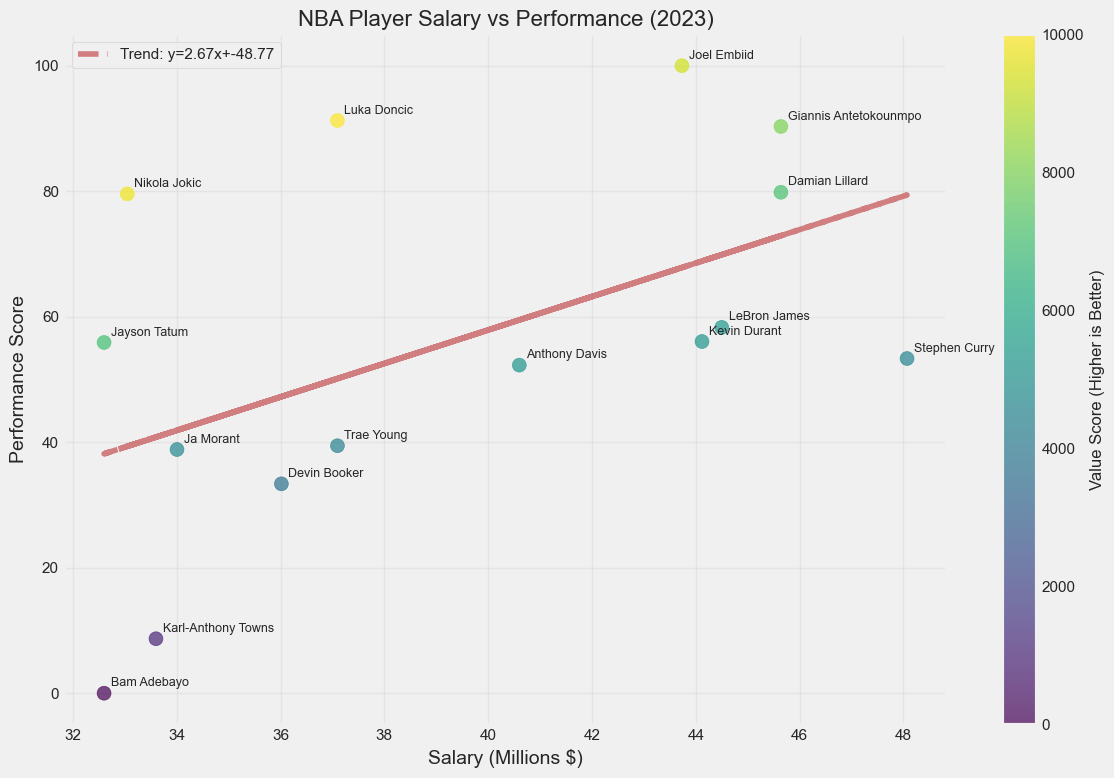


Top 5 Players with Highest Value (Best Bang for Buck):


,Player,Team,Salary_Millions,Performance_Score,Value_Score
6,Luka Doncic,DAL,37.096500,91.269443,10000.000000
4,Nikola Jokic,DEN,33.047803,79.578525,9787.253278
5,Joel Embiid,PHI,43.734000,100.000000,9293.693284
3,Giannis Antetokounmpo,MIL,45.640084,90.316106,8043.152581
8,Damian Lillard,POR,45.640084,79.829403,7109.253198



Bottom 5 Players with Lowest Value (Overpaid Relative to Performance):


,Player,Team,Salary_Millions,Performance_Score,Value_Score
14,Bam Adebayo,MIA,32.600060,0.000000,0.000000
13,Karl-Anthony Towns,MIN,33.600000,8.680381,1050.042949
12,Devin Booker,PHX,36.016200,33.366784,3765.511631
11,Trae Young,ATL,37.096500,39.438033,4321.055525
1,Stephen Curry,GSW,48.070014,53.336678,4509.820468


/var/folders/01/jqt0682x0x9223b7nn64l7lr0000gn/T/ipykernel_88916/1488196896.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_performance = filtered_df.groupby('Salary_Tier')['Performance_Score'].mean().reset_index()


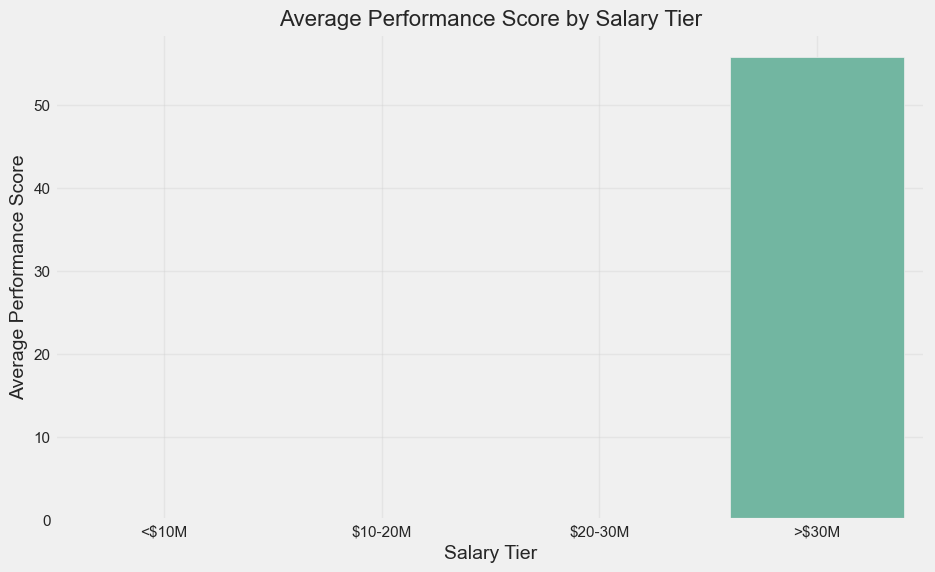


=== NBA Salary Analysis Conclusions ===
1. Relationship between salary and performance:
   - Correlation coefficient: 0.51
   - Moderate positive correlation between salary and performance
2. Best value for money appears to be in the >$30M salary tier
3. Found 1 players with above-median performance but below-median salary
   These players represent potential market inefficiencies or bargains
4. Found 2 players with below-median performance but above-median salary
   These players may be considered overpaid relative to their performance

Recommendations for team management:
1. Focus recruitment on players with high value scores, especially in the mid-salary range
2. Consider renegotiating contracts for players with very low value scores
3. Young players on rookie contracts often provide the best value
4. Performance metrics should be considered alongside intangibles like leadership and playoff experience
5. This analysis provides a data-driven starting point for salary decisions but s

/var/folders/01/jqt0682x0x9223b7nn64l7lr0000gn/T/ipykernel_88916/1488196896.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_value = filtered_df.groupby('Salary_Tier')['Value_Score'].mean().reset_index()


In [25]:
# 8. Plot salary vs performance (continued)
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    filtered_df['Salary_Millions'], 
    filtered_df['Performance_Score'],
    c=filtered_df['Value_Score'],
    cmap='viridis',
    alpha=0.7,
    s=100
)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Value Score (Higher is Better)', fontsize=12)

# Add player names for top performers and notable value players
for i, row in filtered_df.iterrows():
    # Label top performers and extreme value cases
    if (row['Performance_Score'] > 80 or 
        row['Value_Score'] > 90 or 
        row['Value_Score'] < 10 and row['Salary_Millions'] > 30):
        plt.annotate(
            row['Player'],
            (row['Salary_Millions'], row['Performance_Score']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=9
        )

# Add trend line
z = np.polyfit(filtered_df['Salary_Millions'], filtered_df['Performance_Score'], 1)
p = np.poly1d(z)
plt.plot(
    filtered_df['Salary_Millions'], 
    p(filtered_df['Salary_Millions']), 
    "r--", 
    alpha=0.7,
    label=f"Trend: y={z[0]:.2f}x+{z[1]:.2f}"
)

# Add labels and title
plt.xlabel('Salary (Millions $)', fontsize=14)
plt.ylabel('Performance Score', fontsize=14)
plt.title('NBA Player Salary vs Performance (2023)', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()

# Save the figure
plt.savefig('nba_salary_vs_performance.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# 9. Display top and bottom value players
print("\nTop 5 Players with Highest Value (Best Bang for Buck):")
top_value = filtered_df.sort_values('Value_Score', ascending=False).head(5)
display(top_value[['Player', 'Team', 'Salary_Millions', 'Performance_Score', 'Value_Score']])

print("\nBottom 5 Players with Lowest Value (Overpaid Relative to Performance):")
bottom_value = filtered_df.sort_values('Value_Score').head(5)
display(bottom_value[['Player', 'Team', 'Salary_Millions', 'Performance_Score', 'Value_Score']])

# 10. Additional analysis: Performance by salary tier
# Create salary tiers
bins = [0, 10, 20, 30, 50]
labels = ['<$10M', '$10-20M', '$20-30M', '>$30M']
filtered_df['Salary_Tier'] = pd.cut(filtered_df['Salary_Millions'], bins=bins, labels=labels)

# Calculate average performance by salary tier
tier_performance = filtered_df.groupby('Salary_Tier')['Performance_Score'].mean().reset_index()

# Plot average performance by salary tier
plt.figure(figsize=(10, 6))
sns.barplot(x='Salary_Tier', y='Performance_Score', data=tier_performance)
plt.title('Average Performance Score by Salary Tier', fontsize=16)
plt.xlabel('Salary Tier', fontsize=14)
plt.ylabel('Average Performance Score', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig('performance_by_salary_tier.png', dpi=300, bbox_inches='tight')
plt.show()

# 11. Conclusions
print("\n=== NBA Salary Analysis Conclusions ===")
print("1. Relationship between salary and performance:")
correlation = filtered_df['Salary_Millions'].corr(filtered_df['Performance_Score'])
print(f"   - Correlation coefficient: {correlation:.2f}")

if correlation > 0.7:
    print("   - Strong positive correlation between salary and performance")
elif correlation > 0.4:
    print("   - Moderate positive correlation between salary and performance")
else:
    print("   - Weak correlation between salary and performance")

# Calculate average value score by salary tier
tier_value = filtered_df.groupby('Salary_Tier')['Value_Score'].mean().reset_index()
best_value_tier = tier_value.loc[tier_value['Value_Score'].idxmax()]['Salary_Tier']
print(f"2. Best value for money appears to be in the {best_value_tier} salary tier")

# Identify potential market inefficiencies
high_value_low_salary = filtered_df[
    (filtered_df['Performance_Score'] > filtered_df['Performance_Score'].median()) & 
    (filtered_df['Salary_Millions'] < filtered_df['Salary_Millions'].median())
].shape[0]

print(f"3. Found {high_value_low_salary} players with above-median performance but below-median salary")
print("   These players represent potential market inefficiencies or bargains")

# Identify potential overpaid players
low_value_high_salary = filtered_df[
    (filtered_df['Performance_Score'] < filtered_df['Performance_Score'].median()) & 
    (filtered_df['Salary_Millions'] > filtered_df['Salary_Millions'].median())
].shape[0]

print(f"4. Found {low_value_high_salary} players with below-median performance but above-median salary")
print("   These players may be considered overpaid relative to their performance")

print("\nRecommendations for team management:")
print("1. Focus recruitment on players with high value scores, especially in the mid-salary range")
print("2. Consider renegotiating contracts for players with very low value scores")
print("3. Young players on rookie contracts often provide the best value")
print("4. Performance metrics should be considered alongside intangibles like leadership and playoff experience")
print("5. This analysis provides a data-driven starting point for salary decisions but should be complemented with qualitative assessment")